# Not Using Pauli Frame Update

In [2]:
from qiskit import __version__
print(__version__)

2.1.1


In [24]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace, DensityMatrix, Pauli
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.controlflow import IfElseOp
from qiskit.circuit.library import XGate, ZGate
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List

In [4]:
import sys
sys.path.append('Steane')
import importlib
import steane_ec_decoder
importlib.reload(steane_ec_decoder)
from steane_ec_decoder import lookup

In [39]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [59]:
# Custom Hadamard 
h_sub = QuantumCircuit(1, name='H_custom')
h_sub.h(0)
H_custom = h_sub.to_gate()

# Custom CNOT 
cx_sub = QuantumCircuit(2, name='CX_custom')
cx_sub.cx(0, 1)
CX_custom = cx_sub.to_gate()

# Custom RY
ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

# Custom -RY
neg_ry_sub = QuantumCircuit(1, name='N_RY_custom')
neg_ry_sub.ry(-theta, 0)
N_RY_custom = neg_ry_sub.to_gate()

# Function for Encoding

In [67]:
def encoding(qc: QuantumCircuit, first_qubit: int):
    qc.ry(theta, 0)
    for i in range(4, 7):
        qc.h(first_qubit+i)
    qc.cx(first_qubit, first_qubit+1)
    qc.cx(first_qubit, first_qubit+2)
    qc.cx(first_qubit+6, first_qubit)
    qc.cx(first_qubit+6, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit)
    qc.cx(first_qubit+6, first_qubit+3)
    qc.cx(first_qubit+5, first_qubit+2)
    qc.cx(first_qubit+4, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+2)
    qc.cx(first_qubit+4, first_qubit+3)

def inverse_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.cx(first_qubit+4, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+2)
    qc.cx(first_qubit+5, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit+2)
    qc.cx(first_qubit+6, first_qubit+3)
    qc.cx(first_qubit+5, first_qubit)
    qc.cx(first_qubit+6, first_qubit+1)
    qc.cx(first_qubit+6, first_qubit)
    qc.cx(first_qubit, first_qubit+2)
    qc.cx(first_qubit, first_qubit+1)
    for i in range(4, 7):
        qc.h(first_qubit+i)
    qc.ry(-theta, 0)

In [60]:
def perfect_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.append(RY_custom, [first_qubit])
    for i in range(4, 7):
        qc.append(H_custom, [first_qubit+i])
    qc.append(CX_custom, [first_qubit, first_qubit+1])
    qc.append(CX_custom, [first_qubit, first_qubit+2])
    qc.append(CX_custom, [first_qubit+6, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+3])
    qc.append(CX_custom, [first_qubit+5, first_qubit+2])
    qc.append(CX_custom, [first_qubit+4, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+2])
    qc.append(CX_custom, [first_qubit+4, first_qubit+3])
    
def inverse_perfect_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.append(CX_custom, [first_qubit+4, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+2])
    qc.append(CX_custom, [first_qubit+5, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit+2])
    qc.append(CX_custom, [first_qubit+6, first_qubit+3])
    qc.append(CX_custom, [first_qubit+5, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+1])
    qc.append(CX_custom, [first_qubit+6, first_qubit])
    qc.append(CX_custom, [first_qubit, first_qubit+2])
    qc.append(CX_custom, [first_qubit, first_qubit+1])
    for i in range(4, 7):
        qc.append(H_custom, [first_qubit+i])
    qc.append(N_RY_custom, [first_qubit])

# Functions for Stabilizer Extraction 

In [9]:
def flag(qc: QuantumCircuit, first_qubit: int, c1: ClassicalRegister, c2: ClassicalRegister):
    qc.h(first_qubit+7)
    
    qc.cx(first_qubit+7, first_qubit+4)
    qc.cx(first_qubit+6, first_qubit+8)
    qc.cx(first_qubit+5, first_qubit+9)
    qc.cx(first_qubit+7, first_qubit+9)
    qc.cx(first_qubit+7, first_qubit)
    qc.cx(first_qubit+4, first_qubit+8)
    qc.cx(first_qubit+1, first_qubit+9)
    qc.cx(first_qubit+7, first_qubit+2)
    qc.cx(first_qubit+3, first_qubit+8)
    qc.cx(first_qubit+6, first_qubit+9)
    qc.cx(first_qubit+7, first_qubit+8)
    qc.cx(first_qubit+7, first_qubit+6)
    qc.cx(first_qubit+5, first_qubit+8)
    qc.cx(first_qubit+2, first_qubit+9)
    
    qc.h(first_qubit+7)
    qc.measure([first_qubit+7, first_qubit+8, first_qubit+9], c1)
    qc.reset([first_qubit+7, first_qubit+8, first_qubit+9])
    
    qc.h(first_qubit+8)
    qc.h(first_qubit+9)
    
    qc.cx(first_qubit+4, first_qubit+7)
    qc.cx(first_qubit+8, first_qubit+6)
    qc.cx(first_qubit+9, first_qubit+5)
    qc.cx(first_qubit+9, first_qubit+7)
    qc.cx(first_qubit, first_qubit+7)
    qc.cx(first_qubit+8, first_qubit+4)
    qc.cx(first_qubit+9, first_qubit+1)
    qc.cx(first_qubit+2, first_qubit+7)
    qc.cx(first_qubit+8, first_qubit+3)
    qc.cx(first_qubit+9, first_qubit+6)
    qc.cx(first_qubit+8, first_qubit+7)
    qc.cx(first_qubit+6, first_qubit+7)
    qc.cx(first_qubit+8, first_qubit+5)
    qc.cx(first_qubit+9, first_qubit+2)
    
    qc.h(first_qubit+8)
    qc.h(first_qubit+9)
    qc.measure([first_qubit+7, first_qubit+8, first_qubit+9], c2)

# Function for QEC

In [10]:
def QEC(qc: QuantumCircuit, first_qubit: int, c1: ClassicalRegister, c2: ClassicalRegister):
    flag(qc, first_qubit, c1, c2)

# Encoding + 1 Round of EC

In [14]:
ideal = QuantumCircuit(7)
perfect_encoding(ideal, 0)
ideal = DensityMatrix(ideal)


err_rates = []
for i in range(2, 16):
    err_rates.append(np.round(0.0002*i, 4))
logical_error_rates = []
unc = []
for p1 in err_rates:
    #################################################################################
    # Error model
    p2 = p1 * 10
    noise_model = NoiseModel()

    noise_model.add_all_qubit_quantum_error(depolarizing_error(p1,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p1,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p1,1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(p2,2), ['cx'])

    # 0.5% chance of flipping 0 <-> 1
    readout_err = ReadoutError([[1-p2, p2],  # P(measured 0 | actual 0), P(1 | 0)
                                [p2, 1-p2]]) # P(0 | 1), P(1 | 1)

    # Apply to all qubits being measured
    noise_model.add_readout_error(readout_err, [7]) 
    noise_model.add_readout_error(readout_err, [8])
    noise_model.add_readout_error(readout_err, [9])
    #################################################################################
    # Encoding + 1 Round of EC and running shots
    qc = QuantumCircuit(10)

    c1 = ClassicalRegister(3, "c1")
    c2 = ClassicalRegister(3, "c2")

    qc.add_register(c1, c2)

    encoding(qc, 0)
    QEC(qc, 0, c1, c2)

    qc.save_statevector(label='statevector_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=noise_model)
    transpiled = transpile(qc, backend, optimization_level=0)
    job = backend.run(transpiled, shots=100_000, memory=True)
    result = job.result()
    memory = result.get_memory()
    #################################################################################
    # Create array with keys (hex results) and values (statevectors)
    hex_to_sv = []
    hex_mem = result.data()['memory']

    seen = defaultdict(int)
    for mem in hex_mem:
        idx = seen[mem]
        val = result.data()['statevector_post'][mem][idx]
        hex_to_sv.append({mem:val})
        seen[mem] += 1
    #################################################################################
    # Apply corrections to each statevector in above array
    sv_correction = []
    for i, result in enumerate(hex_to_sv):
        hex, sv10 = next(iter(result.items()))
        correction_x, correction_z = lookup(memory[i])
        if (correction_x is None or correction_z is None):
            continue
        correction_z = "I"*3 + correction_z[::-1]
        correction_x = "I"*3 + correction_x[::-1]
        Pauli_cz = Pauli(correction_z)
        Pauli_cx = Pauli(correction_x)
        sv10 = sv10.evolve(Pauli_cz)
        sv10 = sv10.evolve(Pauli_cx)
        sv_correction.append(sv10)
    #################################################################################
    # Count the correct outputs
    sum = 0
    for sv in sv_correction:
        sv = partial_trace(sv, [7, 8, 9])
        if (sv == ideal):
        #if (np.round(state_fidelity(sv, ideal)) == 1.0):
            sum += 1
    #################################################################################
    # Computing uncertainty and add to uncertainty array
    num_meas = len(sv_correction)
    error_rate = sum / num_meas
    unc.append(1.96 * np.sqrt( (error_rate * (1 - error_rate) / num_meas) ))
    #################################################################################
    # Add logical error rate to resulting array
    logical_error_rates.append(1 - (sum / len(sv_correction)))

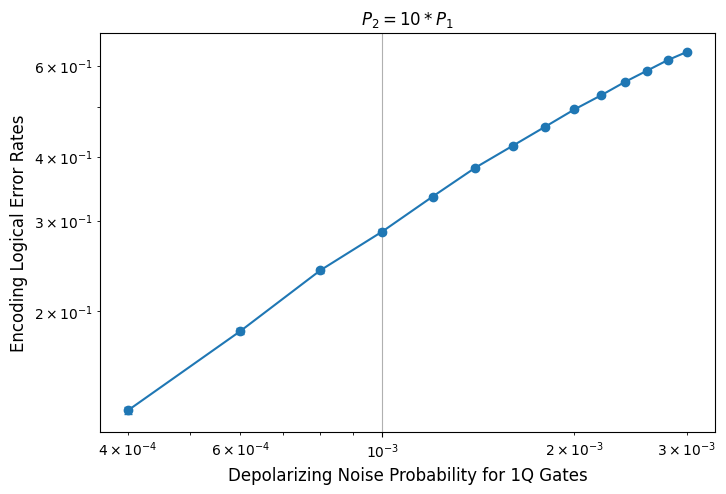

In [15]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    err_rates,
    logical_error_rates,
    yerr=unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Encoding Logical Error Rates", fontsize=12)
plt.title(f"$P_2 = 10 * P_1$")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

# Each rep is encoding + inverse encoding, then decode

In [81]:
def decoder(memory: List[str]):
    shots = len(memory)
    error = 0
    
    for i in range(shots):
        stab1 = (int(memory[i][0]) + int(memory[i][2]) + int(memory[i][4]) + int(memory[i][6])) % 2
        stab2 = (int(memory[i][3]) + int(memory[i][4]) + int(memory[i][5]) + int(memory[i][6])) % 2
        stab3 = (int(memory[i][1]) + int(memory[i][2]) + int(memory[i][5]) + int(memory[i][6])) % 2
        checks = [stab1, stab2, stab3]
        op = (int(memory[i][4]) + int(memory[i][5]) + int(memory[i][6])) % 2
        
        if (checks[1] == 1):
            pass
        elif (checks[0] == 1 or checks[2] == 1):
            op = (op + 1) % 2
        
        if (op == 1):
            error += 1
    
    err_rate = error/shots
    unc = 1.96 * np.sqrt( (err_rate * (1 - err_rate) / shots ))
    return err_rate, unc

In [124]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

Text(0, 0.5, 'logical error')

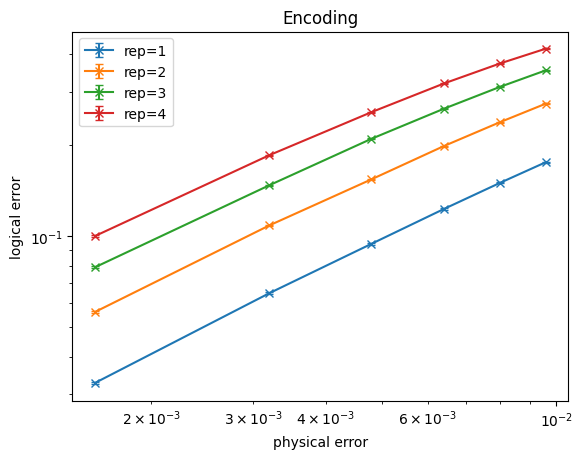

In [140]:
all_error = []
all_unc = []
for rep in range(1, 5):
    logical_error_rates = []
    unc = []
    for noise in range(len(one_qubit_noise)):
        #################################################################################
        # Error model
        noise_model = NoiseModel()
        
        #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cx'])

        # chance of flipping 0 <-> 1
        readout_err = ReadoutError([[1-meas_noise[noise], meas_noise[noise]],  # P(measured 0 | actual 0), P(1 | 0)
                                    [meas_noise[noise], 1-meas_noise[noise]]]) # P(0 | 1), P(1 | 1)

        # Apply to all qubits being measured
        noise_model.add_readout_error(readout_err, [0]) 
        noise_model.add_readout_error(readout_err, [1])
        noise_model.add_readout_error(readout_err, [2])
        noise_model.add_readout_error(readout_err, [3])
        noise_model.add_readout_error(readout_err, [4])
        noise_model.add_readout_error(readout_err, [5])
        noise_model.add_readout_error(readout_err, [6])
        #################################################################################
        qc = QuantumCircuit(7)
        c = ClassicalRegister(7, "c")
        qc.add_register(c)

        for i in range(rep):
            encoding(qc, 0)
            inverse_encoding(qc, 0)
        qc.measure([0, 1, 2, 3, 4, 5, 6], c)
        #################################################################################
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend, optimization_level=0)
        job = backend.run(transpiled, shots=1_000_000, memory=True)
        result = job.result()
        memory = result.get_memory()
        #################################################################################
        err_rate, u = decoder(memory)
        logical_error_rates.append(err_rate)
        unc.append(u)
    
    plt.errorbar(
        two_qubit_noise,
        logical_error_rates,
        yerr=unc,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    all_error.append(logical_error_rates)
    all_unc.append(unc)
    
plt.title('Encoding')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('logical error')

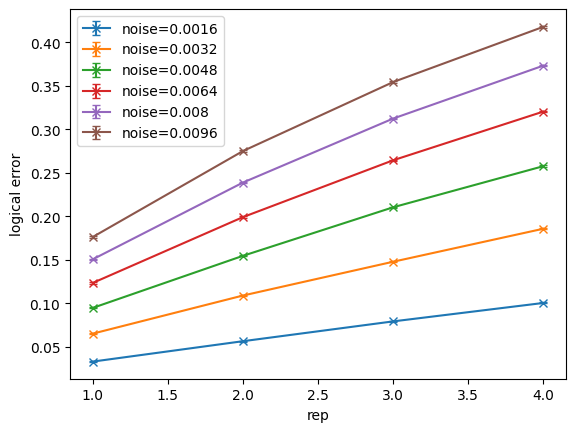

In [141]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_error = np.array(all_error)
all_unc = np.array(all_unc)
num_reps, num_noises = all_error.shape

x = range(1, 5)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_error[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={two_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('logical error')
plt.show()

In [142]:
x = np.array(list(range(1, 5)))   
slopes = []

for k, noise in enumerate(two_qubit_noise):
    y = all_error[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.4f} → slope = {m:.4f} per rep")

noise=0.0016 → slope = 0.0225 per rep
noise=0.0032 → slope = 0.0401 per rep
noise=0.0048 → slope = 0.0546 per rep
noise=0.0064 → slope = 0.0657 per rep
noise=0.0080 → slope = 0.0743 per rep
noise=0.0096 → slope = 0.0806 per rep
